In [1]:


# In[1]:
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

# In[2]:  -------------------- User knobs (edit these) --------------------
casa = True
test = False
mode =  "validation"#"minimal_rho"
era = "2016"            # "2016", "2016APV", "2017", "2018", "all"
data = True# True => data, False => MC
dataset = "pythia"      # for MC: "pythia", "herwig", "st", "powheg", "backgrounds"
pre = 'validation_'
systematics_list = None#['nominal']
jet_systematics_list = None#['nominal']

systematics_list = ['nominal']
jet_systematics_list = ['nominal']
chunksize = 200000
chunksize_test = 200000

group_mode = "per_group"  #"all_in_one" # "per_group" (run list-of-lists separately) or "all_in_one" (flatten and run once)

prependstr = "root://xcache/"  # can swap to "root://cmsxrootd.fnal.gov/" etc.

In [2]:
# HT bins only used for pythia (your convention)
ht_bins = ['100to200','200to400','400to600','600to800','800to1200','1200to2500','2500toInf']

# Paths relative to notebook working dir
SAMPLES_DATA_DIR = "samples"
SAMPLES_MC_DIR   = "samples_mc"
SAMPLES_BKG_DIR  = "samples_mc/backgrounds"

# In[3]:  -------------------- Sample lists (list-of-lists is intentional) --------------------
class SamplePath:
    """Holds list-of-lists so you can run per-group or all-in-one."""

    def __init__(self, era: str):
        self.era = era

        if era == "all":
            self.data = [
                ['SingleMuon_UL2018.txt', 'EGamma_UL2018.txt'],
                ['SingleMuon_UL2017.txt', 'SingleElectron_UL2017.txt'],
                ['SingleMuon_UL2016APV.txt', 'SingleElectron_UL2016APV.txt'],
                ['SingleMuon_UL2016.txt', 'SingleElectron_UL2016.txt'],
            ]
            self.pythia = [
                ['pythia_UL16NanoAODAPVv9.txt'],
                ['pythia_UL16NanoAODv9.txt'],
                ['pythia_UL17NanoAODv9.txt'],
                ['pythia_UL18NanoAODv9.txt'],
            ]
            self.herwig = [
                ['herwig7_UL16NanoAODAPVv9_inclusive.txt'],
                ['herwig7_UL16NanoAODv9_inclusive.txt'],
                ['herwig7_UL17NanoAODv9_inclusive.txt'],
                ['herwig7_UL18NanoAODv9_inclusive.txt'],
            ]

        elif era == "2018":
            self.data   = [['SingleMuon_UL2018.txt', 'EGamma_UL2018.txt']]
            self.pythia = [['pythia_UL18NanoAODv9.txt']]
            self.herwig = [['herwig7_UL18NanoAODv9_inclusive.txt']]

        elif era == "2017":
            self.data   = [['SingleMuon_UL2017.txt', 'SingleElectron_UL2017.txt']]
            self.pythia = [['pythia_UL17NanoAODv9.txt']]
            self.herwig = [['herwig7_UL17NanoAODv9_inclusive.txt']]

        elif era == "2016APV":
            self.data   = [['SingleMuon_UL2016APV.txt', 'SingleElectron_UL2016APV.txt']]
            self.pythia = [['pythia_UL16NanoAODAPVv9.txt']]
            self.herwig = [['herwig7_UL16NanoAODAPVv9_inclusive.txt']]

        elif era == "2016":
            self.data   = [['SingleMuon_UL2016.txt', 'SingleElectron_UL2016.txt']]
            self.pythia = [['pythia_UL16NanoAODv9.txt']]
            self.herwig = [['herwig7_UL16NanoAODv9_inclusive.txt']]

        else:
            raise ValueError(f"Unknown era: {era}")

samplePath = SamplePath(era)

# In[4]:  -------------------- Imports (do once) --------------------
import os
import time
import pickle
import importlib
from pathlib import Path

import numpy as np
import awkward as ak
import uproot

import coffea
from coffea.nanoevents import NanoAODSchema
from coffea import processor

# local package imports
import sys
sys.path.insert(0, os.path.abspath("/work"))
sys.path.insert(0, str(Path.cwd().parent / "src"))
import zjet_corrections
import zjet_corrections.zjet_processor
importlib.reload(zjet_corrections.zjet_processor)
from zjet_corrections.zjet_processor import QJetMassProcessor

In [3]:
# from zjet_corrections.roccor import RoccoR

# rocc = RoccoR("../src/zjet_corrections/corrections/muonSF/UL2016/RoccoR2016aUL.txt")

# #k = rocc.kScaleDT(np.array([1,1]), np.array([100,100]), np.array([1.2,1.2]), np.array([0.2,0.2]))
# k = rocc.kScaleMC(np.array([1,1]), np.array([100,100]), np.array([1.2,1.2]), np.array([0.2,0.2]))
# k2 = rocc.kSmearMC(np.array([1,1]), np.array([100,100]), np.array([1.2,1.2]), np.array([0.2,0.2]), n=np.array([4,4]), u=np.array([0.5,0.5]))
# k

In [4]:
# In[5]:  -------------------- Helpers --------------------
NanoAODSchema.warn_missing_crossrefs = False

def format_time(seconds: float) -> str:
    hours, remainder = divmod(int(seconds), 3600)
    minutes, seconds = divmod(remainder, 60)
    if hours:
        return f"{hours}h {minutes}m {seconds}s"
    if minutes:
        return f"{minutes}m {seconds}s"
    return f"{seconds}s"

def iter_groups(list_of_lists, mode: str):
    """Yield groups based on your intended semantics."""
    if mode == "per_group":
        for g in list_of_lists:
            yield g
    elif mode == "all_in_one":
        flat = []
        for g in list_of_lists:
            flat.extend(g)
        yield flat
    else:
        raise ValueError(f"Unknown group_mode: {mode}")

def read_txt_lines(txt_file: str) -> list[str]:
    with open(txt_file) as f:
        return [ln.strip() for ln in f.readlines() if ln.strip()]

def build_fileset_from_txts(
    txt_files: list[str],
    base_dir: str,
    prepend: str,
    split_ht: bool = False,
    ht_bins: list[str] | None = None,
) -> dict[str, list[str]]:
    """Build fileset dict from a list of txt filenames."""
    fileset = {}

    for fname in txt_files:
        sample = fname.split(".")[0]
        fullpath = os.path.join(base_dir, fname)
        lines = read_txt_lines(fullpath)

        if split_ht:
            if not ht_bins:
                raise ValueError("split_ht=True requires ht_bins")
            for ht in ht_bins:
                files = [prepend + ln for ln in lines if ht in ln]
                fileset[f"{sample}_HT-{ht}"] = files
        else:
            fileset[sample] = [prepend + ln for ln in lines]

    # remove empty entries (important for ht bins that might not exist for a given era)
    fileset = {k: v for k, v in fileset.items() if len(v) > 0}
    return fileset

def build_backgrounds_fileset(directory: str, prepend: str) -> dict[str, list[str]]:
    fileset = {}
    for fname in os.listdir(directory):
        if not fname.endswith(".txt"):
            continue
        core = fname[:-4]  # remove .txt
        idx = core.find("UL")
        if idx == -1:
            print(f"⚠️  'UL' not found in {core}, skipping")
            continue
        sample = core[:idx]
        era_version = core[idx:]
        key = f"{sample}_{era_version}"

        lines = read_txt_lines(os.path.join(directory, fname))
        fileset[key] = [prepend + ln for ln in lines]
    return fileset

def make_runner(
    use_dask: bool = False,
    client=None,
    workers: int = 1,
    chunksize: int = 200_000,
    maxchunks: int | None = 1,
    skipbadfiles: bool = True,
):
    if use_dask:
        if client is None:
            raise ValueError("use_dask=True but no Dask client provided.")
        executor = processor.DaskExecutor(
            client=client,
            status=True,
            retries=3,
            treereduction=4,
        )
    else:
        executor = processor.FuturesExecutor(
            workers=workers,
            status=True,
            compression=None,
        )

    return processor.Runner(
        executor=executor,
        schema=NanoAODSchema,
        chunksize=chunksize,
        maxchunks=maxchunks,
        skipbadfiles=skipbadfiles,
    )

def ensure_client(casa: bool, test: bool):
    """Create a Dask client only when needed."""
    if test:
        print("Running locally with 1-2 files (test=True)")
        return None

    from dask.distributed import Client
    if casa:
        from coffea_casa import CoffeaCasaCluster
        cluster = CoffeaCasaCluster(memory="8 GiB")
        cluster.adapt(minimum=0, maximum=150)
        client = Client(cluster)
        print("✅ Dask client created (CoffeaCasaCluster).")
        return client

    # If you want a non-casa distributed client, put it here.
    print("ℹ️ casa=False: running without distributed client.")
    return None

def upload_package_if_casa(client, casa: bool):
    """Optional: zip + upload local package to workers."""
    if not casa or client is None:
        return

    import shutil
    import pathlib

    pkg_dir = pathlib.Path("/home/cms-jovyan/new_git/zjet_corrections/src/zjet_corrections")
    zip_path = pathlib.Path("/tmp/zjet_corrections.zip")
    if zip_path.exists():
        zip_path.unlink()

    shutil.make_archive(zip_path.with_suffix(""), "zip", pkg_dir.parent, pkg_dir.name)
    client.upload_file(str(zip_path))
    print("📦 Uploaded zjet_corrections.zip to workers.")

def run_once(fileset: dict[str, list[str]], client, test: bool, data: bool, chunksize = 100000, chunksize_test = 100000):
    print("Running over:", list(fileset.keys())[:10], "..." if len(fileset) > 10 else "")
    systematics = None

    # keep your current choices (adjust anytime)
    if data:
        jet_systematics = ["nominal"]
        systematics = ["nominal"]
    else:
        jet_systematics = jet_systematics_list # you sometimes used JMR/JMS here; keep it simple and edit as needed
        systematics = systematics_list

    if test:
        # pick first sample, first file
        
        k0 = list(fileset.keys())[1]
        fileset = {k0: [fileset[k0][0]]}
        print("🧪 Running over test files:", list(fileset.keys()))
        run = make_runner(use_dask=False, client=client, chunksize=chunksize_test, maxchunks=10)
        debug = True
    else:
        print("🚀 Running over full dataset")
        run = make_runner(use_dask=True, client=client, chunksize=chunksize, maxchunks=None)
        debug = False

    t0 = time.time()
    out = run(
        fileset,
        "Events",
        processor_instance=QJetMassProcessor(
            do_gen=not data,
            debug=debug,
            systematics=systematics,
            jet_systematics=jet_systematics,
            mode=mode,
        ),
    )
    print(f"✅ Done. time taken {format_time(time.time() - t0)}")
    return out

def save_output(out, fout: str):
    with open(fout, "wb") as f:
        pickle.dump(out, f)
    size = os.path.getsize(fout)
    unit = "kB" if size < 1e6 else "MB"
    value = size / (1e3 if unit == "kB" else 1e6)
    print(f"💾 Output written to {fout} with size {value:.1f} {unit}")



In [5]:
# In[6]:  -------------------- Create client --------------------
client = ensure_client(casa=casa, test=test)
upload_package_if_casa(client, casa=casa)

{'memory': '8 GiB', 'protocol': 'tls://', 'security': Security(require_encryption=True, tls_ca_file=Local (/etc/cmsaf-secrets/ca.pem), tls_client_cert=Local (/etc/cmsaf-secrets/hostcert.pem), tls_client_key=Local (/etc/cmsaf-secrets/hostcert.pem), tls_min_version=771, tls_scheduler_cert=Local (/etc/cmsaf-secrets/hostcert.pem), tls_scheduler_key=Local (/etc/cmsaf-secrets/hostcert.pem), tls_worker_cert=Local (/etc/cmsaf-secrets/hostcert.pem), tls_worker_key=Local (/etc/cmsaf-secrets/hostcert.pem)), 'log_directory': 'logs', 'silence_logs': 'DEBUG', 'scheduler_options': {'port': 8786, 'dashboard_address': '8787', 'protocol': 'tls', 'contact_address': 'tls://aritra-2emandal-40cern-2ech.dask.cmsaf-prod.flatiron.hollandhpc.org:8786'}, 'job_extra_directives': {'universe': 'docker', 'docker_image': 'hub.opensciencegrid.org/coffea-casa/cc-analysis-alma9:2025.05.24', 'container_service_names': 'dask,nanny', 'dask_container_port': 8786, 'nanny_container_port': 8001, 'use_x509userproxy': False, 'tr

2026-03-05 16:46:25,603 - distributed.scheduler - INFO - State start
2026-03-05 16:46:25,701 - distributed.scheduler - INFO -   Scheduler at: tls://192.168.197.201:8786
2026-03-05 16:46:25,703 - distributed.scheduler - INFO -   dashboard at:  /user/aritra.mandal@cern.ch/proxy/8787/status
2026-03-05 16:46:25,703 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-03-05 16:46:25,713 - distributed.deploy.adaptive - INFO - Adaptive scaling started: minimum=0 maximum=150
2026-03-05 16:46:25,722 - distributed.scheduler - INFO - Receive client connection: Client-d97aacee-18b2-11f1-98ae-8e8f101ad19e
2026-03-05 16:46:25,723 - distributed.core - INFO - Starting established connection to tls://192.168.197.201:54140


✅ Dask client created (CoffeaCasaCluster).


2026-03-05 16:46:29,816 - distributed.utils - INFO - Reload module zjet_corrections from .zip file
2026-03-05 16:46:29,839 - distributed.scheduler - INFO - Registering Worker plugin /tmp/zjet_corrections.zip1eef893a-3854-43f0-aedc-c2a79c97e461


📦 Uploaded zjet_corrections.zip to workers.


2026-03-05 16:47:45,964 - distributed.scheduler - INFO - Register worker addr: tls://129.93.182.113:36291 name: htcondor--25569781.0--
2026-03-05 16:47:45,979 - distributed.scheduler - INFO - Starting worker compute stream, tls://129.93.182.113:36291
2026-03-05 16:47:45,980 - distributed.core - INFO - Starting established connection to tls://192.168.86.10:45528
2026-03-05 16:47:46,071 - distributed.scheduler - INFO - Register worker addr: tls://129.93.182.116:38061 name: htcondor--25569782.0--
2026-03-05 16:47:46,090 - distributed.scheduler - INFO - Starting worker compute stream, tls://129.93.182.116:38061
2026-03-05 16:47:46,091 - distributed.core - INFO - Starting established connection to tls://192.168.86.10:45566
2026-03-05 16:47:46,093 - distributed.scheduler - INFO - Register worker addr: tls://129.93.182.102:43253 name: htcondor--25569783.0--
2026-03-05 16:47:46,106 - distributed.scheduler - INFO - Starting worker compute stream, tls://129.93.182.102:43253
2026-03-05 16:47:46,1

In [6]:
# In[7]:  -------------------- Build fileset(s) and run --------------------
outs = []  # keep multiple outputs if you run multiple groups

if data:
    for group in iter_groups(samplePath.data, group_mode):
        fileset = build_fileset_from_txts(group, SAMPLES_DATA_DIR, prependstr, split_ht=False)
        outs.append(run_once(fileset, client=client, test=test, data=True))

else:
    if dataset == "pythia":
        for group in iter_groups(samplePath.pythia, group_mode):
            fileset = build_fileset_from_txts(group, SAMPLES_MC_DIR, prependstr, split_ht=True, ht_bins=ht_bins)
            outs.append(run_once(fileset, client=client, test=test, data=False, chunksize = chunksize, chunksize_test = chunksize_test))

    elif dataset == "pythia2":
        fileset = build_fileset_from_txts(
            ["inclusive_UL16NanoAODv9.txt"],
            SAMPLES_MC_DIR,
            prependstr,
            split_ht = False
        )
        outs.append(run_once(fileset, client = client, test = test, data = False, chunksize = chunksize, chunksize_test = chunksize_test))
    elif dataset == "herwig":
        for group in iter_groups(samplePath.herwig, group_mode):
            fileset = build_fileset_from_txts(group, SAMPLES_MC_DIR, prependstr, split_ht=False)
            outs.append(run_once(fileset, client=client, test=test, data=False))

    elif dataset == "powheg":
        fileset = build_fileset_from_txts(
            ["powheg_UL18NanoAODv9_inclusive.txt"],
            SAMPLES_MC_DIR,
            prependstr,
            split_ht=False,
        )
        outs.append(run_once(fileset, client=client, test=test, data=False, chunksize = chunksize, chunksize_test = chunksize_test))

    elif dataset == "st":
        st_files = [
            'st_tW_antitop_UL16NanoAODv9.txt',
            'st_tW_antitop_UL16NanoAODAPVv9.txt',
            'st_tW_antitop_UL17NanoAODv9.txt',
            'st_tW_antitop_UL18NanoAODv9.txt',
            'st_tW_top_UL16NanoAODv9.txt',
            'st_tW_top_UL16NanoAODAPVv9.txt',
            'st_tW_top_UL17NanoAODv9.txt',
            'st_tW_top_UL18NanoAODv9.txt',
            'ST_t-channel_antitop_4f_InclusiveDecays_UL16NanoAODv9.txt',
            'ST_t-channel_antitop_4f_InclusiveDecays_UL16NanoAODAPVv9.txt',
            'ST_t-channel_antitop_4f_InclusiveDecays_UL17NanoAODv9.txt',
            'ST_t-channel_antitop_4f_InclusiveDecays_UL18NanoAODv9.txt',
            'ST_t-channel_top_4f_InclusiveDecays_UL16NanoAODv9.txt',
            'ST_t-channel_top_4f_InclusiveDecays_UL16NanoAODAPVv9.txt',
            'ST_t-channel_top_4f_InclusiveDecays_UL17NanoAODv9.txt',
            'ST_t-channel_top_4f_InclusiveDecays_UL18NanoAODv9.txt',
        ]
        fileset = build_fileset_from_txts(st_files, SAMPLES_MC_DIR, prependstr, split_ht=False)
        outs.append(run_once(fileset, client=client, test=test, data=False))

    elif dataset == "backgrounds":
        fileset = build_backgrounds_fileset(SAMPLES_BKG_DIR, prependstr)
        outs.append(run_once(fileset, client=client, test=test, data=False))

    else:
        print(f"Dataset is {dataset} and it is not in the list")
        #raise ValueError("Please specify correct dataset")

# In[8]:  -------------------- Choose what to keep in `out` --------------------
# If you ran multiple groups, keep them all in `outs`, and also expose last output as `out`.
out = outs[-1] if len(outs) else None


# In[10]:  -------------------- Analysis / plotting zone --------------------
# Keep plotting down here so the 'run' block stays clean.
# (Your existing plotting cells can remain, just moved below this line.)

# In[ ]:
# Example:
# import hist
# import matplotlib.pyplot as plt
# out['ptjet_rhojet_g_reco'].project('dataset','ptreco','mpt_reco')[:,1,:].plot(stack=False)
# plt.legend()

# In[ ]:
# Close client when you're done

print(f"Number of group outputs: {len(outs)}")

# Name each group output clearly
if era == "all" and group_mode == "per_group":
    group_tags = ["2016", "2016APV", "2017", "2018"]
else:
    # fallback: group0, group1, ...
    group_tags = [era]

# Save one file per group
for i, out_i in enumerate(outs):
    tag = group_tags[i] if i < len(group_tags) else f"group{i}"
    fout = f"{pre}{'data' if data else dataset}_{tag}{'_TEST' if test else ''}.pkl"
    save_output(out_i, fout)

# Still expose the last output in `out` for convenience in notebook plotting
out = outs[-1] if outs else None

if client is not None:
    client.close()

Running over: ['SingleMuon_UL2016', 'SingleElectron_UL2016'] 
🚀 Running over full dataset
[########################################] | 100% Completed |  5min 50.4s

/home/cms-jovyan/new_git/zjet_corrections/src/zjet_corrections/hist_utils.py:23: UserWarning: Please use 'Weight()' instead of 'Weight'
  hnew = hist.Hist(
/usr/local/lib/python3.10/site-packages/hist/basehist.py:417: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


✅ Done. time taken 7m 47s
Number of group outputs: 1
💾 Output written to validation_data_2016.pkl with size 121.9 kB


In [7]:
for key in out.keys():
    if key in ("sumw", "nev", "cutflow"):
        continue
    print(key, out[key].sum())

pt_mupos WeightedSum(value=29616, variance=29616)
eta_mupos WeightedSum(value=29616, variance=29616)
phi_mupos WeightedSum(value=29616, variance=29616)
pt_muneg WeightedSum(value=29616, variance=29616)
eta_muneg WeightedSum(value=29616, variance=29616)
phi_muneg WeightedSum(value=29616, variance=29616)
y_mupos WeightedSum(value=29616, variance=29616)
y_muneg WeightedSum(value=29616, variance=29616)
pt_elpos WeightedSum(value=14967, variance=14967)
eta_elpos WeightedSum(value=14967, variance=14967)
phi_elpos WeightedSum(value=14967, variance=14967)
pt_elneg WeightedSum(value=14967, variance=14967)
eta_elneg WeightedSum(value=14967, variance=14967)
phi_elneg WeightedSum(value=14967, variance=14967)
y_elpos WeightedSum(value=14967, variance=14967)
y_elneg WeightedSum(value=14967, variance=14967)
nJets WeightedSum(value=44583, variance=44583)
pt_Z WeightedSum(value=44583, variance=44583)
eta_Z WeightedSum(value=44574, variance=44574)
phi_Z WeightedSum(value=44583, variance=44583)
mass_Z We

Text(0.5, 0, 'pT of positive muon')

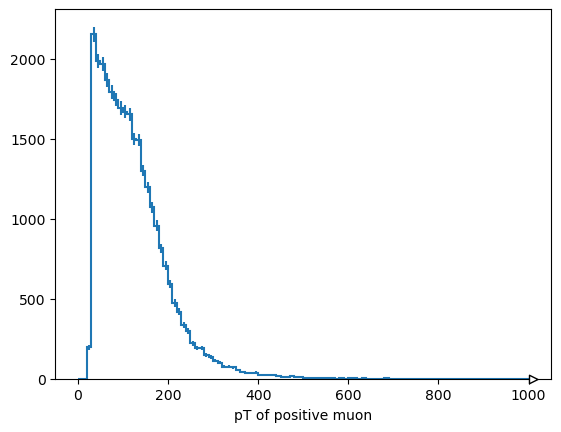

In [8]:

import hist
import matplotlib.pyplot as plt
out['pt_mupos'].project('pt')[hist.loc(0):hist.loc(1000)].plot()
plt.xlabel("pT of positive muon")
#out['ht_AK4'].project('pt').plot()

Text(0.5, 0, 'pT of Z candidate')

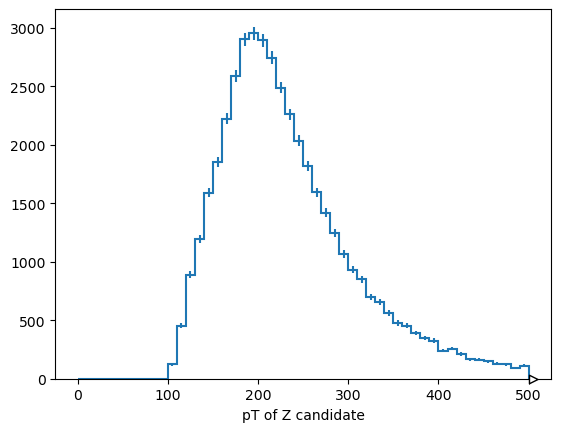

In [9]:
import hist
import matplotlib.pyplot as plt
out['pt_Z'].project('pt')[hist.loc(0):hist.loc(500)].plot()
plt.xlabel("pT of Z candidate")

Text(0.5, 0, 'pT of leading electron')

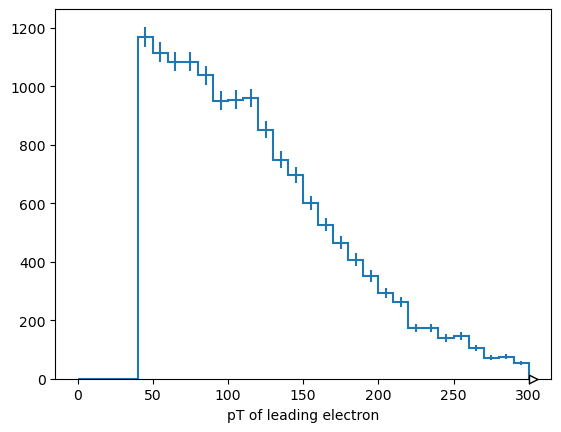

In [10]:
import hist
import matplotlib.pyplot as plt
out['pt_elpos'].project('pt')[hist.loc(0):hist.loc(300)].plot()
plt.xlabel("pT of leading electron")

Text(0.5, 0, 'eta of leading electron')

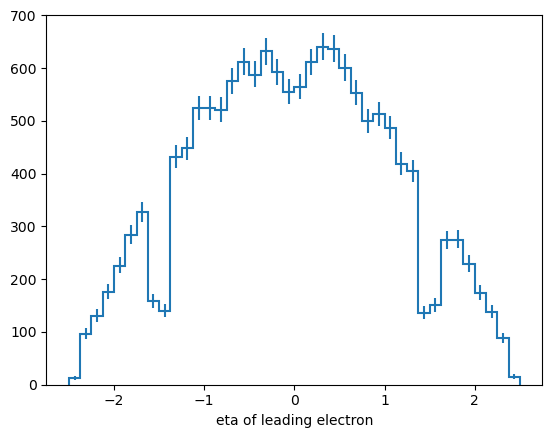

In [11]:
import hist
import matplotlib.pyplot as plt
out['eta_elneg'].project('eta').plot()
plt.xlabel("eta of leading electron")

Text(0.5, 0, 'y of leading electron')

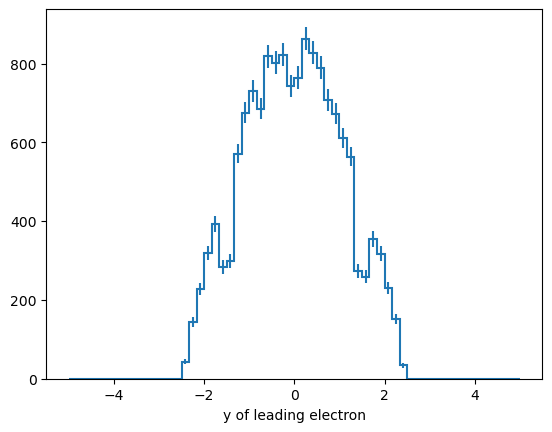

In [12]:
import hist
import matplotlib.pyplot as plt
out['y_elneg'].project('y').plot()
plt.xlabel("y of leading electron")

Text(0.5, 0, 'pT of leading electron')

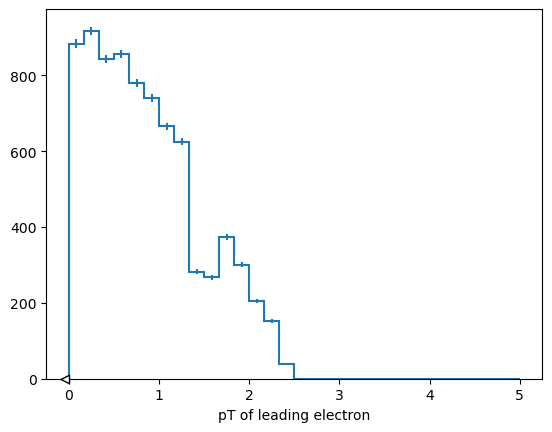

In [13]:
import hist
import matplotlib.pyplot as plt
out['y_elpos'].project('y')[hist.loc(0):hist.loc(300)].plot()
plt.xlabel("pT of leading electron")

In [8]:
import matplotlib.pyplot as plt
import mplhep as hep
import hist
from cycler import cycler
hep.style.use("CMS")
# Set tab20 as the default color cycle
plt.rc('axes', prop_cycle=(cycler(color=plt.cm.tab20.colors)))

out['ht_AK4'].project('ht_bin', 'pt')[["HT-100to200", "HT-200to400","HT-400to600", "HT-600to800", "HT-800to1200", "HT-1200to2500", "HT-2500toInf"], hist.loc(0):].plot(stack = False, histtype = "fill")
plt.xlabel(r"$HT_{}$")
plt.yscale("log")
plt.legend()

KeyError: "'HT-100to200' not in axis"

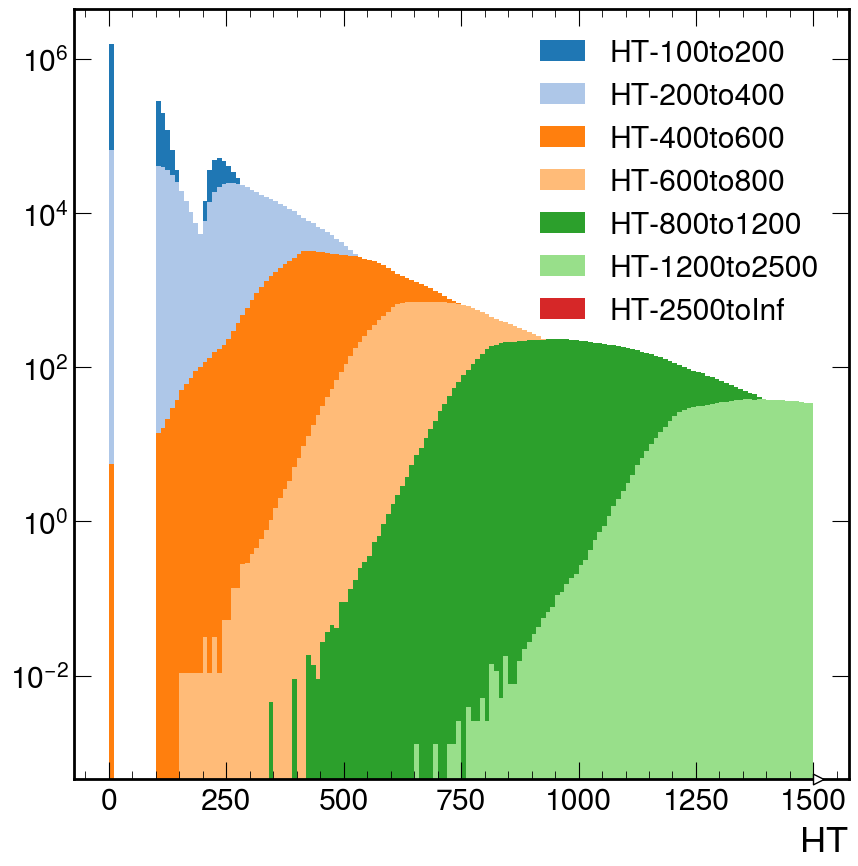

In [15]:
import matplotlib.pyplot as plt
import mplhep as hep
import hist
from cycler import cycler
hep.style.use("CMS")
# Set tab20 as the default color cycle
plt.rc('axes', prop_cycle=(cycler(color=plt.cm.tab20.colors)))

out['ht'].project('ht_bin', 'pt')[["HT-100to200", "HT-200to400","HT-400to600", "HT-600to800", "HT-800to1200", "HT-1200to2500", "HT-2500toInf"], hist.loc(0):].plot(stack = False, histtype = "fill")
plt.xlabel(r"$HT_{}$")
plt.yscale("log")
plt.legend()

In [7]:
out['dphi'].project('dataset', 'dphi')[['zz_UL17NanoAODv9', 'zz_UL18NanoAODv9'], :].plot()

KeyError: "'zz_UL17NanoAODv9' not in axis"

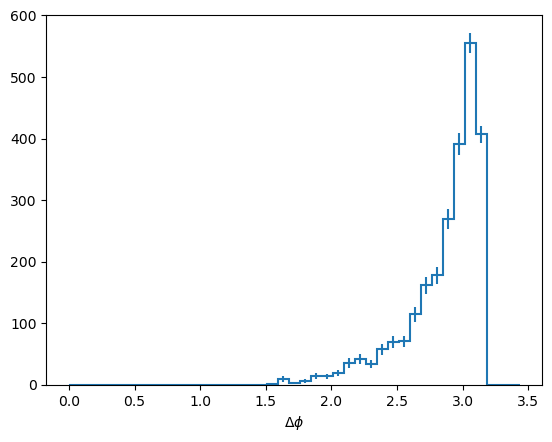

In [25]:
import hist
out['dphi'].project('systematic','dphi')[:,hist.loc (0):hist.loc(3.5)].plot()
import matplotlib.pyplot as plt


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f7aea9a65f0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f7aea8010f0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f7aea824190>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f7aea827100>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f7aea8c2230>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f7ae9f2936

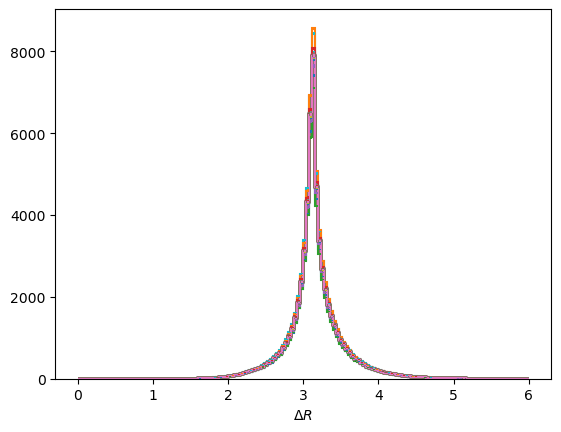

In [8]:
out['dr'].project('systematic','dr').plot()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f6d2c4622c0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

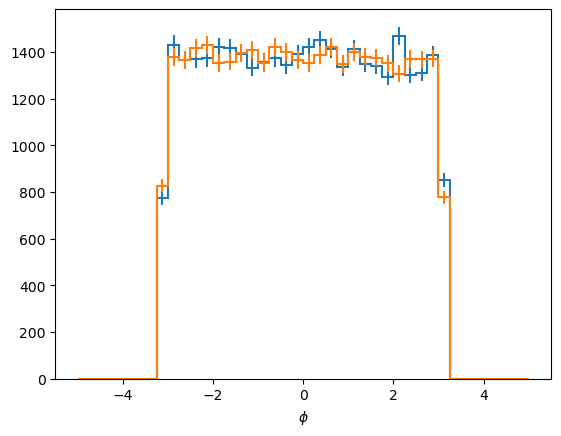

In [9]:
out['phi_mu0'].project('phi').plot()
out['phi_mu1'].project('phi').plot()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f6d2dcc8ac0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

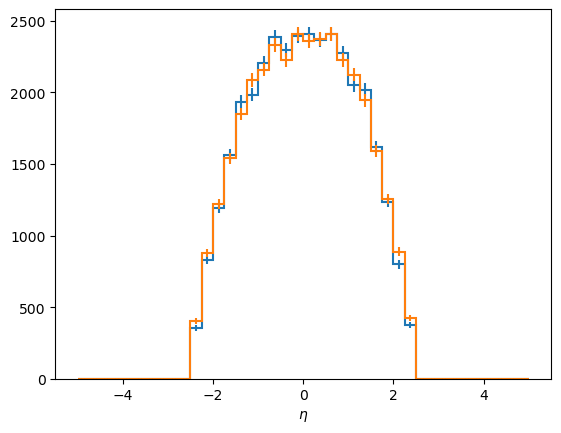

In [10]:
out['eta_mu0'].project('eta').plot()
out['eta_mu1'].project('eta').plot()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f99ce4b1540>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

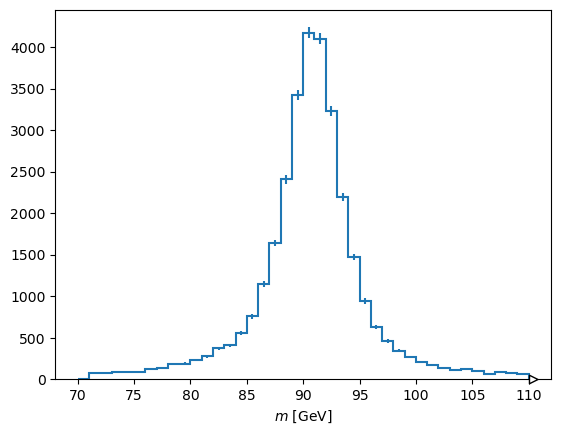

In [7]:
out['mass_Z'].project('mass').plot()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f99d6a78a90>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

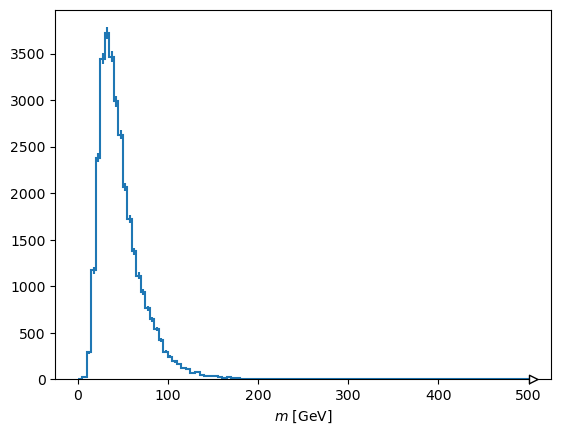

In [6]:
out['mass_jet0'].project('mass').plot()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fa622015240>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

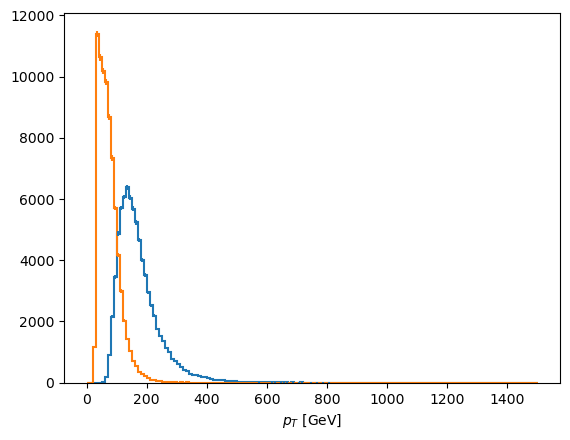

In [11]:
out['pt_mu0'].project('pt').plot()
out['pt_mu1'].project('pt').plot()


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f4260136710>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

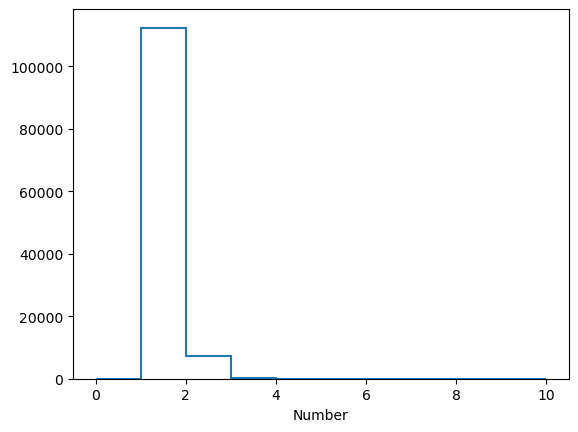

In [17]:
out['nJets'].project('n').plot()

In [ ]:
import pickle as pkl
with open('herwig_2018.pkl', 'rb') as f:
    out_h = pkl.load(f)
    

/tmp/ipykernel_84/1289956400.py:15: RuntimeWarning: invalid value encountered in divide
  ratio1 = val1/val0
/tmp/ipykernel_84/1289956400.py:16: RuntimeWarning: invalid value encountered in divide
  ratio2 = val2/val0


(0.8, 1.2)

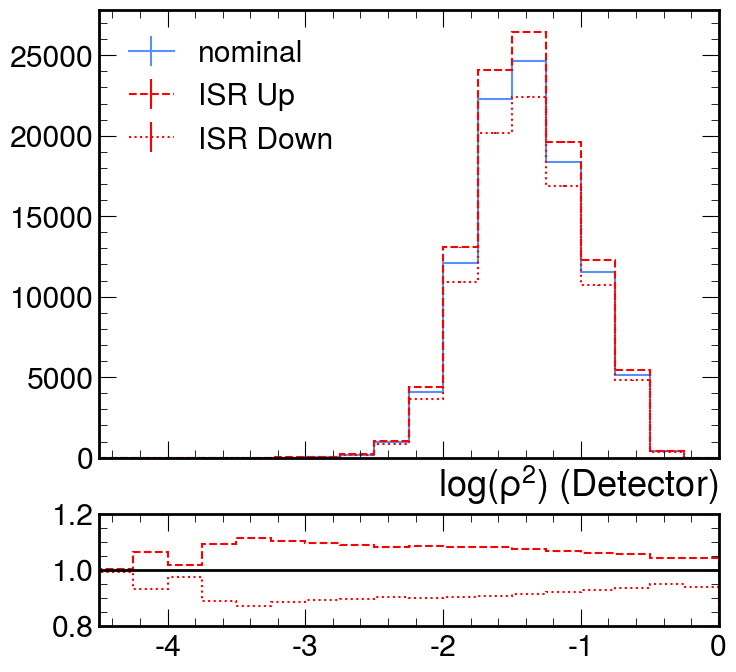

In [62]:
import mplhep as hep
hep.style.use("CMS")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [4, 1]})
plt.sca(ax1)
out['ptjet_rhojet_u_reco'].project('systematic','mpt_reco')['nominal', :].plot(label = "nominal",)
out['ptjet_rhojet_u_reco'].project('systematic','mpt_reco')['isrUp', :].plot(label = "ISR Up", ls = '--', color = 'Red')
out['ptjet_rhojet_u_reco'].project('systematic','mpt_reco')['isrDown', :].plot(label = "ISR Down", ls = 'dotted', color = 'Red')
#out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['fsrUp', :].plot(label = "FSR Up", ls = '--')
plt.legend()
plt.sca(ax2)
val0 = out['ptjet_rhojet_u_reco'].project('systematic','mpt_reco')['nominal', :].values()
val1 = out['ptjet_rhojet_u_reco'].project('systematic','mpt_reco')['isrUp', :].values()
val2 = out['ptjet_rhojet_u_reco'].project('systematic','mpt_reco')['isrDown', :].values()
ratio1 = val1/val0
ratio2 = val2/val0
plt.stairs(ratio1, out['ptjet_rhojet_u_reco'].project('systematic','mpt_reco')['isrUp', :].axes[0].edges, color = 'r', ls = '--', lw = 1.5)
plt.stairs(ratio2, out['ptjet_rhojet_u_reco'].project('systematic','mpt_reco')['isrUp', :].axes[0].edges, color = 'r', ls = 'dotted', lw = 1.5)
plt.hlines(1.0, -10.8, 1.0, lw = 2, color = 'k')
plt.xlim(-4.5, 0)
plt.ylim(0.8, 1.2)

/tmp/ipykernel_84/2986560769.py:15: RuntimeWarning: invalid value encountered in divide
  ratio1 = val1/val0
/tmp/ipykernel_84/2986560769.py:16: RuntimeWarning: invalid value encountered in divide
  ratio2 = val2/val0


(0.8, 1.2)

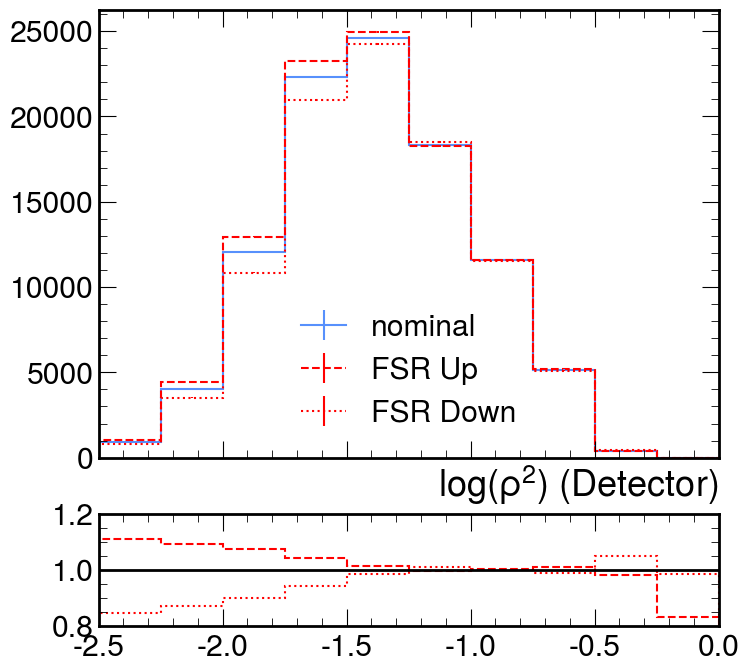

In [64]:
import mplhep as hep
hep.style.use("CMS")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [4, 1]})
plt.sca(ax1)
out['ptjet_rhojet_u_reco'].project('systematic','mpt_reco')['nominal', :].plot(label = "nominal",)
out['ptjet_rhojet_u_reco'].project('systematic','mpt_reco')['fsrUp', :].plot(label = "FSR Up", ls = '--', color = 'Red')
out['ptjet_rhojet_u_reco'].project('systematic','mpt_reco')['fsrDown', :].plot(label = "FSR Down", ls = 'dotted', color = 'Red')
#out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['fsrUp', :].plot(label = "FSR Up", ls = '--')
plt.legend()
plt.sca(ax2)
val0 = out['ptjet_rhojet_u_reco'].project('systematic','mpt_reco')['nominal', :].values()
val1 = out['ptjet_rhojet_u_reco'].project('systematic','mpt_reco')['fsrUp', :].values()
val2 = out['ptjet_rhojet_u_reco'].project('systematic','mpt_reco')['fsrDown', :].values()
ratio1 = val1/val0
ratio2 = val2/val0
plt.stairs(ratio1, out['ptjet_rhojet_u_reco'].project('systematic','mpt_reco')['fsrUp', :].axes[0].edges, color = 'r', ls = '--', lw = 1.5)
plt.stairs(ratio2, out['ptjet_rhojet_u_reco'].project('systematic','mpt_reco')['fsrUp', :].axes[0].edges, color = 'r', ls = 'dotted', lw = 1.5)
plt.hlines(1.0, -10.8, 1.0, lw = 2, color = 'k')
plt.xlim(-2.5, 0)
plt.ylim(0.8, 1.2)

(0.8, 1.2)

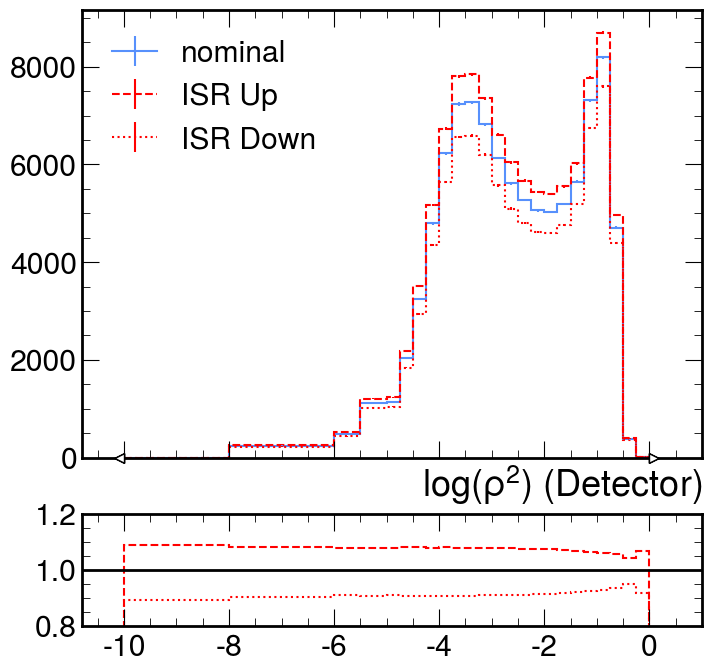

In [58]:
import mplhep as hep
hep.style.use("CMS")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [4, 1]})
plt.sca(ax1)
out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['nominal', :].plot(label = "nominal",)
out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['isrUp', :].plot(label = "ISR Up", ls = '--', color = 'Red')
out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['isrDown', :].plot(label = "ISR Down", ls = 'dotted', color = 'Red')
#out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['fsrUp', :].plot(label = "FSR Up", ls = '--')
plt.legend()
plt.sca(ax2)
val0 = out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['nominal', :].values()
val1 = out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['isrUp', :].values()
val2 = out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['isrDown', :].values()
ratio1 = val1/val0
ratio2 = val2/val0
plt.stairs(ratio1, out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['isrUp', :].axes[0].edges, color = 'r', ls = '--', lw = 1.5)
plt.stairs(ratio2, out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['isrUp', :].axes[0].edges, color = 'r', ls = 'dotted', lw = 1.5)
plt.hlines(1.0, -10.8, 1.0, lw = 2, color = 'k')
plt.xlim(-10.8, 1)
plt.ylim(0.8, 1.2)

(0.8, 1.2)

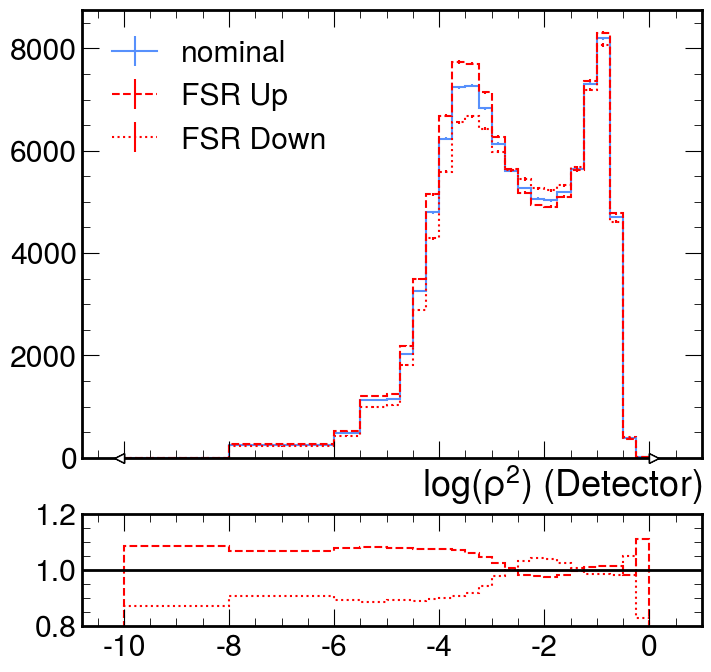

In [59]:
import mplhep as hep
hep.style.use("CMS")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [4, 1]})
plt.sca(ax1)
out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['nominal', :].plot(label = "nominal",)
out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['fsrUp', :].plot(label = "FSR Up", ls = '--', color = 'Red')
out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['fsrDown', :].plot(label = "FSR Down", ls = 'dotted', color = 'Red')
#out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['fsrUp', :].plot(label = "FSR Up", ls = '--')
plt.legend()
plt.sca(ax2)
val0 = out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['nominal', :].values()
val1 = out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['fsrUp', :].values()
val2 = out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['fsrDown', :].values()
ratio1 = val1/val0
ratio2 = val2/val0
plt.stairs(ratio1, out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['fsrUp', :].axes[0].edges, color = 'r', ls = '--', lw = 1.5)
plt.stairs(ratio2, out['ptjet_rhojet_g_reco'].project('systematic','mpt_reco')['fsrUp', :].axes[0].edges, color = 'b', ls = 'dotted', lw = 1.5)
plt.hlines(1.0, -10.8, 1.0, lw = 2, color = 'k')
plt.xlim(-10.8, 1)
plt.ylim(0.8, 1.2)

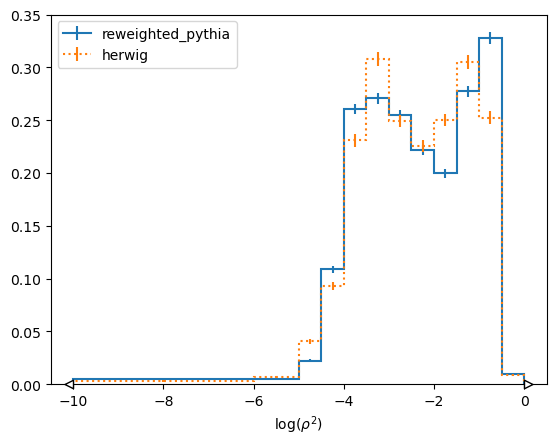

In [8]:
import matplotlib.pyplot as plt
for i in range(1,4):
    out['ptjet_rhojet_g_gen'].project('ptgen','mpt_gen')[i, :].plot(density = True, label = 'reweighted_pythia');
    out_h['ptjet_rhojet_g_gen'].project('ptgen','mpt_gen')[i, :].plot(density = True, ls= 'dotted', label = 'herwig');
    #prev_out.plot(density   = True, label = 'prev', ls = 'dotted')
    plt.legend()
    if i == 1: break

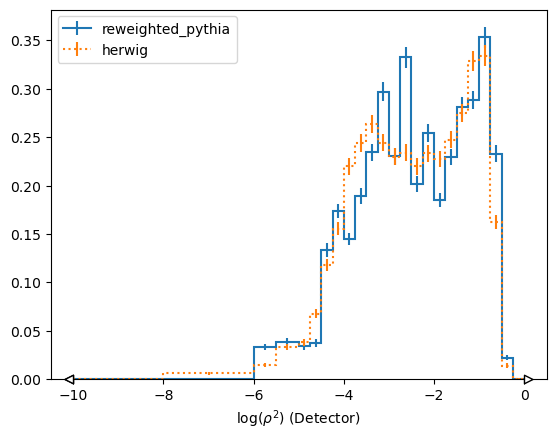

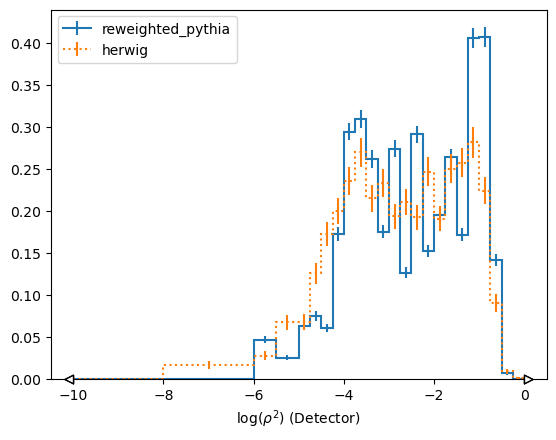

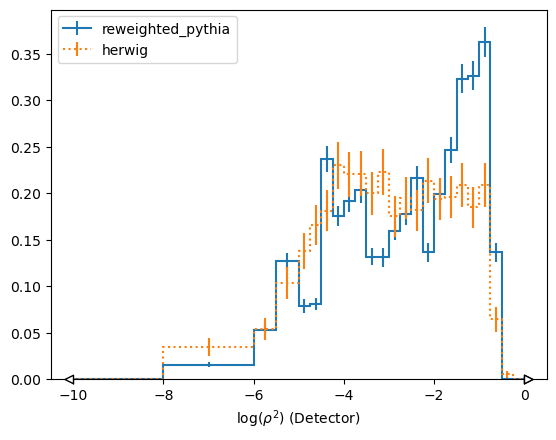

In [10]:
import matplotlib.pyplot as plt
for i in range(1,4):
    out['ptjet_rhojet_g_reco'].project('ptreco','mpt_reco')[i, :].plot(density = True, label = 'reweighted_pythia');
    out_h['ptjet_rhojet_g_reco'].project('ptreco','mpt_reco')[i, :].plot(density = True, ls= 'dotted', label = 'herwig');
    #prev_out.plot(density   = True, label = 'prev', ls = 'dotted')
    plt.legend()
    plt.show()
    if i == 3: break

In [9]:
out['response_matrix_rho_g']

Hist(
  StrCategory(['pythia_UL18NanoAODv9'], name='dataset'),
  Variable([0, 200, 290, 400, 13000], name='ptreco', label='$p_{T,RECO}$ (GeV)'),
  Variable(array([-10.  ,  -8.  ,  -6.  ,  -5.5 ,  -5.  ,  -4.75,  -4.5 ,  -4.25,
        -4.  ,  -3.75,  -3.5 ,  -3.25,  -3.  ,  -2.75,  -2.5 ,  -2.25,
        -2.  ,  -1.75,  -1.5 ,  -1.25,  -1.  ,  -0.75,  -0.5 ,  -0.25,
         0.  ]), name='mpt_reco', label='$\\log(\\rho^2)$ (Detector)'),
  Variable([0, 200, 290, 400, 13000], name='ptgen', label='$p_{T,GEN}$ (GeV)'),
  Variable([-10, -6, -5, -4.5, -4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0], name='mpt_gen', label='$\\log(\\rho^2)$'),
  StrCategory(['nominal'], growth=True, name='systematic', label='Systematic Uncertainty'),
  storage=Weight()) # Sum: WeightedSum(value=98368.4, variance=13079.2) (WeightedSum(value=98599.2, variance=13120.2) with flow)

In [10]:
out['response_matrix_rho_g'].project('mpt_reco').values()

array([7.36133015e-01, 1.90115665e+02, 3.78861754e+02, 1.25266474e+03,
       1.35219924e+03, 2.17029667e+03, 3.17206776e+03, 4.41343917e+03,
       5.48970058e+03, 6.20302850e+03, 6.26420700e+03, 6.05693212e+03,
       5.77788593e+03, 5.71985013e+03, 5.73468684e+03, 5.79370483e+03,
       6.00332601e+03, 6.30358180e+03, 6.53988678e+03, 7.61244572e+03,
       7.67578905e+03, 3.99944412e+03, 2.99137530e+02, 6.95358367e+00])

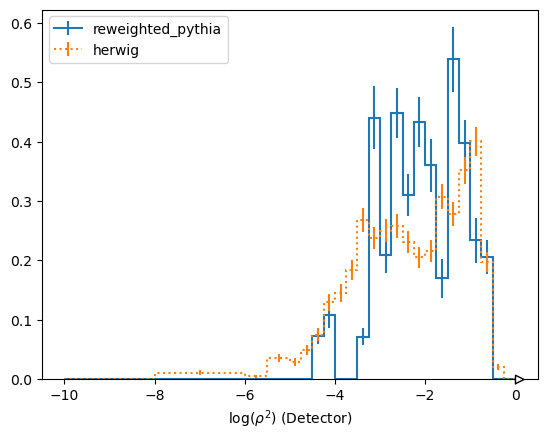

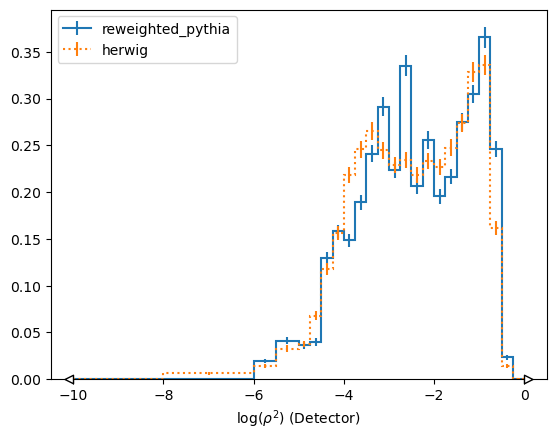

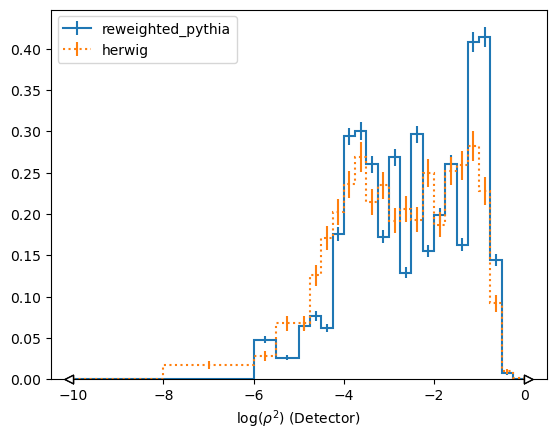

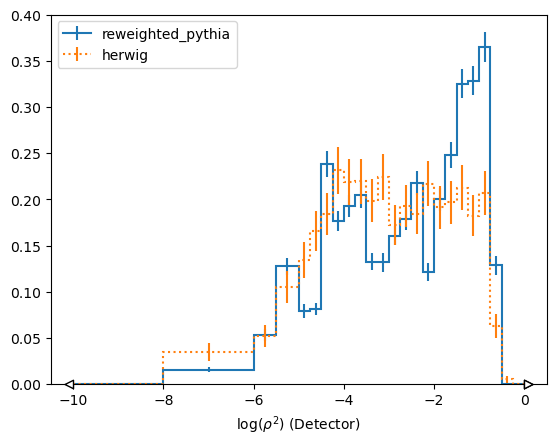

In [13]:
import matplotlib.pyplot as plt
for i in range(4):
    out['response_matrix_rho_g'].project('ptreco','mpt_reco')[i, :].plot(density = True, label = 'reweighted_pythia');
    out_h['response_matrix_rho_g'].project('ptreco','mpt_reco')[i, :].plot(density = True, ls= 'dotted', label = 'herwig');
    #prev_out.plot(density   = True, label = 'prev', ls = 'dotted')
    plt.legend()
    plt.show()
    if i == 3: break